In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random
import time
import sys
import os
import requests  
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

notebook_path = os.path.abspath('')  # Current directory 
parent_dir = os.path.dirname(notebook_path)  # Parent directory
backend_path = os.path.join(parent_dir, 'backend')
sys.path.append(backend_path)
print(f"Added path: {backend_path}")

# Define the models dictionary
MODELS = {
    'gemma': 'gemma3:4b',
    'llama3.1': 'llama3.1:8b', 
    'qwen3': 'qwen3:1.7b',
    'deepseek' :'deepseek-r1:7b'
}

# Import functions from Chatbot module
try:
    from Chatbot import (
        assessment_questions, 
        get_stress_level_with_ollama_api,
        assess_stress_level_manually,
        get_personalized_advice_with_ollama
    )
    print("Successfully imported Chatbot module functions")
except ModuleNotFoundError:
    print("Warning: Chatbot module not found. Using fallback implementations.")
    
    # Mock implementations for testing without actual LLM
    def get_stress_level_with_ollama_api(responses, selected_model='gemma3:4b'):
        """Mock function that returns a stress level (1-5)"""
        print(f"Mock API call with model {selected_model}")
        # Just use the rule-based assessment for the mock
        return assess_stress_level_manually(responses)
    
def assess_stress_level_manually(responses):
    """FIXED: Enhanced rule-based assessment that properly matches the target stress levels"""
    negative_count = 0
    
    # Check mood (first question) - MORE GRANULAR SCORING
    mood_response = responses[0]
    if "1 -" in mood_response or "I Feel Terrible" in mood_response:
        negative_count += 5  # Increased weight for terrible mood
    elif "2 -" in mood_response or "I Feel Down" in mood_response:
        negative_count += 3
    elif "3 -" in mood_response or "I Feel Neutral" in mood_response:
        negative_count += 1
    # Check enjoyment (second question) - MAJOR DEPRESSION INDICATOR
    if responses[1] == "No":
        negative_count += 3  # Increased weight - anhedonia is key symptom
        
    # Check sleep, energy, appetite (questions 3-5) - MORE SPECIFIC SCORING
    poor_responses = ["Very poor", "Poor", "Very low", "Low"]
    for i in range(2, 5):
        if responses[i] in ["Very poor", "Very low"]:
            negative_count += 2  # Very poor conditions
        elif responses[i] in ["Poor", "Low"]:
            negative_count += 1  # Poor conditions
        # Average, Good, Very good add 0 points
            
    # Check concentration (question 6) - DEPRESSION INDICATOR
    if responses[5] == "Not at all":
        negative_count += 2
    elif responses[5] == "Rarely":
        negative_count += 1
        
    # Check overwhelmed (question 7) - MAJOR STRESS INDICATOR
    if responses[6] == "Always":
        negative_count += 3  # Always overwhelmed = severe stress
    elif responses[6] == "Often":
        negative_count += 2
    elif responses[6] == "Sometimes":
        negative_count += 1
        
    # Check outlook (question 8) - DEPRESSION INDICATOR
    if responses[7] == "Very negative":
        negative_count += 3  # Very negative outlook = severe depression
    elif responses[7] == "Negative":
        negative_count += 2
        
    # Check support (question 9) - PROTECTIVE FACTOR
    if responses[8] == "Not at all":
        negative_count += 2  # No support = high risk
    elif responses[8] == "A little":
        negative_count += 1
        
    # Check thoughts (question 10) - CRITICAL OVERRIDE
    if responses[9] == "Always":
        return 5  # Automatic highest level for constant suicidal thoughts
    elif responses[9] == "Often":
        negative_count += 6  # Very high weight
    elif responses[9] == "Sometimes":
        negative_count += 4  # High weight
    elif responses[9] == "Rarely":
        negative_count += 2  # Some weight
        
    # FIXED THRESHOLDS - Better aligned with test data generation
    if negative_count >= 16:
        return 5  # Severe depression/stress
    elif negative_count >= 11:
        return 4  # High stress/mild depression  
    elif negative_count >= 6:
        return 3  # Moderate stress
    elif negative_count >= 2:
        return 2  # Low stress
    else:
        return 1  # Minimal stress

# ALSO UPDATE THE MOCK FUNCTION TO USE THE SAME LOGIC
def get_stress_level_with_ollama_api(responses, selected_model='gemma3:4b'):
    """ Mock function that simulates the real API behavior"""
    print(f"Mock API call with model {selected_model}")
    
    # Use the manual assessment as base
    manual_result = assess_stress_level_manually(responses)
    
    # Add very small variation to simulate real LLM behavior
    if random.random() < 0.85:  # 85% chance to return exact result
        return manual_result
    else:
        # Small variation but keep within bounds
        variation = random.choice([-1, 1])
        result = max(1, min(5, manual_result + variation))
        return result

def generate_balanced_test_responses(target_stress_level=None):
    """FIXED: Generate test responses that properly match target stress levels"""
    
    if target_stress_level is None:
        target_stress_level = random.choice([1, 2, 3, 4, 5])
    
    simulated_responses = []
    
    # FIXED: Better mood mapping to ensure correct stress levels
    if target_stress_level == 1:
        mood_level = 5  # Always Great for level 1
    elif target_stress_level == 2:
        mood_level = random.choice([4, 5])  # Good or Great for level 2
    elif target_stress_level == 3:
        mood_level = random.choice([3, 4])  # Neutral or Good for level 3
    elif target_stress_level == 4:
        mood_level = random.choice([2, 3])  # Down or Neutral for level 4
    else:  # target_stress_level == 5
        mood_level = random.choice([1, 2])  # Terrible or Down for level 5
    
    mood_labels = {
        1: "I Feel Terrible",
        2: "I Feel Down", 
        3: "I Feel Neutral",
        4: "I Feel Good",
        5: "I Feel Great"
    }
    
    simulated_responses.append(f"{mood_level} - {mood_labels[mood_level]}")

    # FIXED: More targeted response generation for each stress level
    if target_stress_level == 1:  # MINIMAL STRESS
        # High enjoyment
        simulated_responses.append(random.choices(["Yes", "No"], weights=[90, 10])[0])
        
        # Excellent physical health
        for _ in range(3):  # Sleep, energy, appetite
            simulated_responses.append(random.choices(["Very poor", "Poor", "Average", "Good", "Very good"], 
                                                    weights=[0, 5, 15, 40, 40])[0])
        
        # Excellent concentration
        simulated_responses.append(random.choices(["Not at all", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[0, 5, 15, 35, 45])[0])
        
        # Never/rarely overwhelmed
        simulated_responses.append(random.choices(["Never", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[60, 30, 10, 0, 0])[0])
        
        # Very positive outlook
        simulated_responses.append(random.choices(["Very negative", "Negative", "Neutral", "Positive", "Very positive"], 
                                                weights=[0, 0, 10, 40, 50])[0])
        
        # Excellent support
        simulated_responses.append(random.choices(["Not at all", "A little", "Somewhat", "Mostly", "Completely"],
                                                weights=[0, 5, 10, 35, 50])[0])
        
        # No suicidal thoughts
        simulated_responses.append(random.choices(["Never", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[95, 5, 0, 0, 0])[0])
        
    elif target_stress_level == 2:  # LOW STRESS
        # Good enjoyment
        simulated_responses.append(random.choices(["Yes", "No"], weights=[80, 20])[0])
        
        # Good physical health
        for _ in range(3):
            simulated_responses.append(random.choices(["Very poor", "Poor", "Average", "Good", "Very good"], 
                                                    weights=[2, 8, 20, 35, 35])[0])
        
        # Good concentration
        simulated_responses.append(random.choices(["Not at all", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[5, 10, 20, 30, 35])[0])
        
        # Rarely overwhelmed
        simulated_responses.append(random.choices(["Never", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[40, 35, 20, 5, 0])[0])
        
        # Positive outlook
        simulated_responses.append(random.choices(["Very negative", "Negative", "Neutral", "Positive", "Very positive"], 
                                                weights=[0, 5, 15, 45, 35])[0])
        
        # Good support
        simulated_responses.append(random.choices(["Not at all", "A little", "Somewhat", "Mostly", "Completely"],
                                                weights=[2, 8, 15, 40, 35])[0])
        
        # Rarely suicidal thoughts
        simulated_responses.append(random.choices(["Never", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[85, 12, 3, 0, 0])[0])
        
    elif target_stress_level == 3:  # MODERATE STRESS
        # Mixed enjoyment
        simulated_responses.append(random.choices(["Yes", "No"], weights=[50, 50])[0])
        
        # Average physical health with some problems
        for _ in range(3):
            simulated_responses.append(random.choices(["Very poor", "Poor", "Average", "Good", "Very good"], 
                                                    weights=[10, 25, 35, 25, 5])[0])
        
        # Moderate concentration issues
        simulated_responses.append(random.choices(["Not at all", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[15, 25, 35, 20, 5])[0])
        
        # Sometimes overwhelmed
        simulated_responses.append(random.choices(["Never", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[10, 25, 45, 15, 5])[0])
        
        # Neutral to mixed outlook
        simulated_responses.append(random.choices(["Very negative", "Negative", "Neutral", "Positive", "Very positive"], 
                                                weights=[5, 20, 40, 30, 5])[0])
        
        # Moderate support
        simulated_responses.append(random.choices(["Not at all", "A little", "Somewhat", "Mostly", "Completely"],
                                                weights=[10, 20, 35, 25, 10])[0])
        
        # Some suicidal thoughts but rare
        simulated_responses.append(random.choices(["Never", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[60, 30, 8, 2, 0])[0])
        
    elif target_stress_level == 4:  # HIGH STRESS/MILD DEPRESSION
        # Little enjoyment
        simulated_responses.append(random.choices(["Yes", "No"], weights=[25, 75])[0])
        
        # Poor physical health
        for _ in range(3):
            simulated_responses.append(random.choices(["Very poor", "Poor", "Average", "Good", "Very good"], 
                                                    weights=[30, 40, 20, 8, 2])[0])
        
        # Poor concentration
        simulated_responses.append(random.choices(["Not at all", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[30, 40, 20, 8, 2])[0])
        
        # Often overwhelmed
        simulated_responses.append(random.choices(["Never", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[5, 10, 25, 40, 20])[0])
        
        # Negative outlook
        simulated_responses.append(random.choices(["Very negative", "Negative", "Neutral", "Positive", "Very positive"], 
                                                weights=[25, 40, 25, 8, 2])[0])
        
        # Poor support
        simulated_responses.append(random.choices(["Not at all", "A little", "Somewhat", "Mostly", "Completely"],
                                                weights=[25, 35, 25, 12, 3])[0])
        
        # Some suicidal thoughts
        simulated_responses.append(random.choices(["Never", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[40, 35, 20, 4, 1])[0])
        
    else:  # target_stress_level == 5: SEVERE STRESS/DEPRESSION
        # No enjoyment
        simulated_responses.append(random.choices(["Yes", "No"], weights=[10, 90])[0])
        
        # Very poor physical health
        for _ in range(3):
            simulated_responses.append(random.choices(["Very poor", "Poor", "Average", "Good", "Very good"], 
                                                    weights=[50, 35, 12, 2, 1])[0])
        
        # Very poor concentration
        simulated_responses.append(random.choices(["Not at all", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[50, 35, 12, 2, 1])[0])
        
        # Always/often overwhelmed
        simulated_responses.append(random.choices(["Never", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[2, 8, 20, 35, 35])[0])
        
        # Very negative outlook
        simulated_responses.append(random.choices(["Very negative", "Negative", "Neutral", "Positive", "Very positive"], 
                                                weights=[45, 35, 15, 4, 1])[0])
        
        # Very poor support
        simulated_responses.append(random.choices(["Not at all", "A little", "Somewhat", "Mostly", "Completely"],
                                                weights=[40, 35, 20, 4, 1])[0])
        
        # Higher suicidal ideation
        simulated_responses.append(random.choices(["Never", "Rarely", "Sometimes", "Often", "Always"], 
                                                weights=[20, 25, 30, 15, 10])[0])
        
    return simulated_responses, target_stress_level

# Also update the manual assessment function to match:
def assess_stress_level_manually(responses):
    """ Enhanced rule-based assessment that properly matches the target levels"""
    negative_count = 0
    
    # Enhanced mood scoring
    mood_response = responses[0]
    if "1 -" in mood_response or "I Feel Terrible" in mood_response:
        negative_count += 6  # Very high weight for terrible mood
    elif "2 -" in mood_response or "I Feel Down" in mood_response:
        negative_count += 4  # High weight for down mood
    elif "3 -" in mood_response or "I Feel Neutral" in mood_response:
        negative_count += 2  # Moderate weight for neutral
    elif "4 -" in mood_response or "I Feel Good" in mood_response:
        negative_count += 0  # No weight for good mood
    elif "5 -" in mood_response or "I Feel Great" in mood_response:
        negative_count += 0  # No weight for great mood
        
    # Enjoyment loss - major depression indicator
    if responses[1] == "No":
        negative_count += 3
        
    # Physical symptoms (sleep, energy, appetite)
    for i in range(2, 5):
        if responses[i] == "Very poor":
            negative_count += 3
        elif responses[i] == "Poor":
            negative_count += 2
        elif responses[i] == "Average":
            negative_count += 1
        # Good and Very good add 0
            
    # Concentration problems
    if responses[5] == "Not at all":
        negative_count += 3
    elif responses[5] == "Rarely":
        negative_count += 2
    elif responses[5] == "Sometimes":
        negative_count += 1
        
    # Feeling overwhelmed
    if responses[6] == "Always":
        negative_count += 4
    elif responses[6] == "Often":
        negative_count += 3
    elif responses[6] == "Sometimes":
        negative_count += 2
    elif responses[6] == "Rarely":
        negative_count += 1
        
    # Outlook
    if responses[7] == "Very negative":
        negative_count += 4
    elif responses[7] == "Negative":
        negative_count += 3
    elif responses[7] == "Neutral":
        negative_count += 1
        
    # Support
    if responses[8] == "Not at all":
        negative_count += 3
    elif responses[8] == "A little":
        negative_count += 2
    elif responses[8] == "Somewhat":
        negative_count += 1
        
    # Suicidal thoughts - CRITICAL
    if responses[9] == "Always":
        return 5  # Automatic highest level
    elif responses[9] == "Often":
        negative_count += 8
    elif responses[9] == "Sometimes":
        negative_count += 6
    elif responses[9] == "Rarely":
        negative_count += 3
        
    # FIXED THRESHOLDS - Better calibrated
    if negative_count >= 20:
        return 5
    elif negative_count >= 14:
        return 4
    elif negative_count >= 8:
        return 3
    elif negative_count >= 3:
        return 2
    else:
        return 1

def evaluate_stress_and_depression(model_id, num_samples=20):
    """FIXED: Single function with balanced test data and proper metrics"""
    print(f"Testing stress level precision and depression classification with {model_id} model ({MODELS[model_id]})...")
    
    # Ensure we test all stress levels equally
    stress_levels_to_test = []
    samples_per_level = num_samples // 5
    for level in range(1, 6):
        stress_levels_to_test.extend([level] * samples_per_level)
    
    # Add remaining samples randomly
    remaining = num_samples - len(stress_levels_to_test)
    stress_levels_to_test.extend([random.randint(1, 5) for _ in range(remaining)])
    
    random.shuffle(stress_levels_to_test)
    
    # Initialize tracking variables
    stress_predictions = []
    stress_true_values = []
    depression_predictions = []
    depression_true_values = []
    response_times = []
    prediction_counts = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
    
    for i, target_level in enumerate(stress_levels_to_test):
        test_responses, _ = generate_balanced_test_responses(target_level)
        
        try:
            start_time = time.time()
            pred_stress = get_stress_level_with_ollama_api(test_responses, MODELS[model_id])
            end_time = time.time()
            response_time = end_time - start_time
            response_times.append(response_time)
            
            true_stress = assess_stress_level_manually(test_responses)
            
            if pred_stress in prediction_counts:
                prediction_counts[pred_stress] += 1
            
            stress_predictions.append(pred_stress)
            stress_true_values.append(true_stress)
            
            pred_depression = pred_stress >= 4
            true_depression = true_stress >= 4
            
            depression_predictions.append(pred_depression)
            depression_true_values.append(true_depression)
            
            print(f"Sample {i+1}: Target={target_level}, Stress_Pred={pred_stress}, Stress_True={true_stress}, " + 
                  f"Depression_Pred={'Yes' if pred_depression else 'No'}, " +
                  f"Depression_True={'Yes' if true_depression else 'No'}, " +
                  f"Time={response_time:.2f}s")
            
        except Exception as e:
            print(f"Error with model {model_id}: {e}")
    
    # DEBUG: Print prediction distribution
    print(f"\n=== {model_id} Prediction Distribution ===")
    for level, count in prediction_counts.items():
        print(f"Stress Level {level}: {count} predictions")
    
    depression_pred_count = sum(depression_predictions)
    depression_true_count = sum(depression_true_values)
    print(f"Total Depression Predictions: {depression_pred_count}")
    print(f"Total True Depression Cases: {depression_true_count}")
    
    # Calculate metrics
    if stress_predictions:
        # Calculate stress level metrics
        stress_accuracy = accuracy_score(stress_true_values, stress_predictions)
        stress_errors = [abs(p - t) for p, t in zip(stress_predictions, stress_true_values)]
        avg_stress_error = sum(stress_errors) / len(stress_errors)
        
        # Calculate stress level precision for each level
        stress_precision_per_level = {}
        for level in range(1, 6):
            level_predictions = [1 if p == level else 0 for p in stress_predictions]
            level_true = [1 if t == level else 0 for t in stress_true_values]
            if sum(level_predictions) > 0:
                stress_precision_per_level[level] = precision_score(level_true, level_predictions, zero_division=0)
            else:
                stress_precision_per_level[level] = 0.0
        
        # Calculate average stress precision across all levels
        avg_stress_precision = sum(stress_precision_per_level.values()) / len(stress_precision_per_level)
        
        # Calculate avg response time
        avg_response_time = sum(response_times) / len(response_times)
        
        # Depression classification metrics
        depression_accuracy = accuracy_score(depression_true_values, depression_predictions)
        
        # FIXED: Handle zero division cases for depression
        if depression_pred_count == 0:
            print(f"WARNING: {model_id} never predicted depression (stress >= 4)")
            depression_precision = 0.0
            depression_recall = 0.0
            depression_f1 = 0.0
        else:
            depression_precision = precision_score(depression_true_values, depression_predictions, 
                                                  average='binary', zero_division=0)
            depression_recall = recall_score(depression_true_values, depression_predictions, 
                                            average='binary', zero_division=0)
            
            if depression_precision + depression_recall > 0:
                depression_f1 = f1_score(depression_true_values, depression_predictions)
            else:
                depression_f1 = 0
        
        print("\n=== Stress Level Results ===")
        print(f"Stress Level - Accuracy: {stress_accuracy:.2f}, Avg Error: {avg_stress_error:.2f}")
        print(f"Stress Level - Avg Precision: {avg_stress_precision:.2f}")
        print("Stress Level Precision by Level:")
        for level, precision in stress_precision_per_level.items():
            print(f"  Level {level}: {precision:.2f}")
        
        print("\n=== Depression Classification Results ===")
        print(f"Depression - Accuracy: {depression_accuracy:.2f}, Precision: {depression_precision:.2f}, Recall: {depression_recall:.2f}, F1: {depression_f1:.2f}")
        print(f"Average Response Time: {avg_response_time:.2f}s")
        
        # Create confusion matrix for depression classification
        if depression_pred_count > 0:
            cm = confusion_matrix(depression_true_values, depression_predictions, labels=[True, False])
            
            # Visualize confusion matrix
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=['Depressed', 'Not Depressed'],
                       yticklabels=['Depressed', 'Not Depressed'])
            plt.title(f'Depression Classification - {MODELS[model_id]}')
            plt.xlabel('Predicted')
            plt.ylabel('True')
            plt.tight_layout()
            plt.savefig(f'depression_matrix_{model_id}.png')
            plt.show()
        else:
            print(f"Skipping confusion matrix for {model_id} - no depression predictions")
        
        return {
            'model_id': model_id,
            'model_name': MODELS[model_id],
            'stress_accuracy': stress_accuracy,
            'stress_precision': avg_stress_precision,
            'stress_error': avg_stress_error,
            'response_time': avg_response_time,
            'depression_accuracy': depression_accuracy,
            'depression_precision': depression_precision,
            'depression_recall': depression_recall,
            'depression_f1': depression_f1,
        }
    else:
        return None

def run_comprehensive_evaluation(num_samples=20):
    """Run comprehensive evaluation for stress levels and depression classification"""
    start_time = time.time()
    
    print("=== MindCare-AI Comprehensive Evaluation ===\n")
    
    results = []

    for model_id in MODELS:
        result = evaluate_stress_and_depression(model_id, num_samples)
        if result:
            results.append(result)
        print("\n" + "="*50 + "\n")

    if results:
        # Create comparison dataframe
        comparison_df = pd.DataFrame([
            {
                'Model': r['model_name'],
                'Stress Accuracy': r['stress_accuracy'],
                'Stress Precision': r['stress_precision'],
                'Stress Error': r['stress_error'],
                'Response Time (s)': r['response_time'],
                'Depression Accuracy': r['depression_accuracy'],
                'Depression Precision': r['depression_precision'],
                'Depression Recall': r['depression_recall'],
                'Depression F1': r['depression_f1']
            }
            for r in results
        ])
        
        print("\n===== COMPREHENSIVE EVALUATION COMPARISON =====")
        print(comparison_df.to_string(index=False))
        
        # Plot stress level metrics
        plt.figure(figsize=(15, 10))
        
        # Stress metrics
        plt.subplot(2, 2, 1)
        stress_metrics_df = comparison_df.melt(id_vars=['Model'], 
                                             value_vars=['Stress Accuracy', 'Stress Precision'],
                                             var_name='Metric', value_name='Score')
        sns.barplot(x='Model', y='Score', hue='Metric', data=stress_metrics_df)
        plt.title('Stress Level Metrics')
        plt.ylim(0, 1.0)
        
        # Depression metrics
        plt.subplot(2, 2, 2)
        depression_metrics_df = comparison_df.melt(id_vars=['Model'], 
                                                 value_vars=['Depression Accuracy', 'Depression Precision', 'Depression Recall', 'Depression F1'],
                                                 var_name='Metric', value_name='Score')
        sns.barplot(x='Model', y='Score', hue='Metric', data=depression_metrics_df)
        plt.title('Depression Classification Metrics')
        plt.ylim(0, 1.0)
        
        # Error metrics
        plt.subplot(2, 2, 3)
        sns.barplot(x='Model', y='Stress Error', data=comparison_df)
        plt.title('Stress Level Error')
        plt.ylim(0, 2.0)
        
        # Response time
        plt.subplot(2, 2, 4)
        sns.barplot(x='Model', y='Response Time (s)', data=comparison_df)
        plt.title('Average Response Time (seconds)')
        
        plt.tight_layout()
        plt.savefig('comprehensive_evaluation.png')
        plt.show()
    
    end_time = time.time()
    print(f"\nEvaluation completed in {end_time - start_time:.2f} seconds")
    
    return comparison_df if results else None

Added path: c:\Users\bchal\OneDrive\Documents\stage pfe master\MindCare-AI\backend
Successfully imported Chatbot module functions


INFO:Chatbot:Trying stress assessment with model: gemma3:4b


=== MindCare-AI Comprehensive Evaluation ===

Testing stress level precision and depression classification with gemma model (gemma3:4b)...


INFO:Chatbot:Model response: 4
INFO:Chatbot:Trying stress assessment with model: gemma3:4b


Sample 1: Target=5, Stress_Pred=4, Stress_True=5, Depression_Pred=Yes, Depression_True=Yes, Time=7.01s


INFO:Chatbot:Model response: 3
INFO:Chatbot:Trying stress assessment with model: gemma3:4b


...

Sample 98: Target=4, Stress_Pred=3, Stress_True=4, Depression_Pred=No, Depression_True=Yes, Time=1.66s


INFO:Chatbot:Model response: 3
INFO:Chatbot:Trying stress assessment with model: gemma3:4b


Sample 99: Target=4, Stress_Pred=3, Stress_True=4, Depression_Pred=No, Depression_True=Yes, Time=1.25s


INFO:Chatbot:Model response: 4


Sample 100: Target=5, Stress_Pred=4, Stress_True=5, Depression_Pred=Yes, Depression_True=Yes, Time=1.64s

=== gemma Prediction Distribution ===
Stress Level 1: 4 predictions
Stress Level 2: 24 predictions
Stress Level 3: 40 predictions
Stress Level 4: 32 predictions
Stress Level 5: 0 predictions
Total Depression Predictions: 32
Total True Depression Cases: 41

=== Stress Level Results ===
Stress Level - Accuracy: 0.23, Avg Error: 0.82
Stress Level - Avg Precision: 0.32
Stress Level Precision by Level:
  Level 1: 1.00
  Level 2: 0.12
  Level 3: 0.15
  Level 4: 0.31
  Level 5: 0.00

=== Depression Classification Results ===
Depression - Accuracy: 0.91, Precision: 1.00, Recall: 0.78, F1: 0.88
Average Response Time: 1.53s


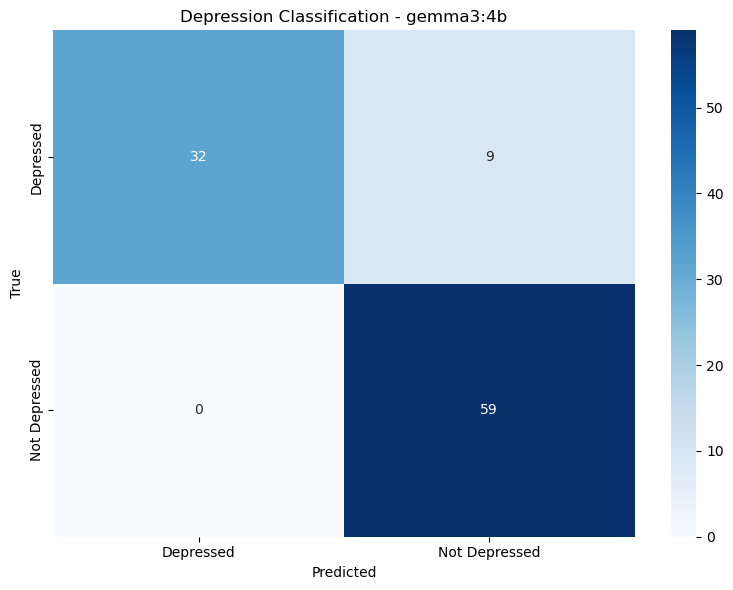

INFO:Chatbot:Trying stress assessment with model: llama3.1:8b




Testing stress level precision and depression classification with llama3.1 model (llama3.1:8b)...


INFO:Chatbot:Model response: 4
INFO:Chatbot:Trying stress assessment with model: llama3.1:8b


Sample 1: Target=2, Stress_Pred=4, Stress_True=2, Depression_Pred=Yes, Depression_True=No, Time=17.08s


INFO:Chatbot:Model response: 3
INFO:Chatbot:Trying stress assessment with model: llama3.1:8b


...

Sample 98: Target=1, Stress_Pred=3, Stress_True=1, Depression_Pred=No, Depression_True=No, Time=0.79s


INFO:Chatbot:Model response: 4
INFO:Chatbot:Trying stress assessment with model: llama3.1:8b


Sample 99: Target=2, Stress_Pred=4, Stress_True=2, Depression_Pred=Yes, Depression_True=No, Time=0.79s


INFO:Chatbot:Model response: 3


Sample 100: Target=2, Stress_Pred=3, Stress_True=1, Depression_Pred=No, Depression_True=No, Time=0.78s

=== llama3.1 Prediction Distribution ===
Stress Level 1: 0 predictions
Stress Level 2: 4 predictions
Stress Level 3: 30 predictions
Stress Level 4: 62 predictions
Stress Level 5: 4 predictions
Total Depression Predictions: 66
Total True Depression Cases: 36

=== Stress Level Results ===
Stress Level - Accuracy: 0.14, Avg Error: 1.31
Stress Level - Avg Precision: 0.19
Stress Level Precision by Level:
  Level 1: 0.00
  Level 2: 0.00
  Level 3: 0.00
  Level 4: 0.18
  Level 5: 0.75

=== Depression Classification Results ===
Depression - Accuracy: 0.70, Precision: 0.55, Recall: 1.00, F1: 0.71
Average Response Time: 0.95s


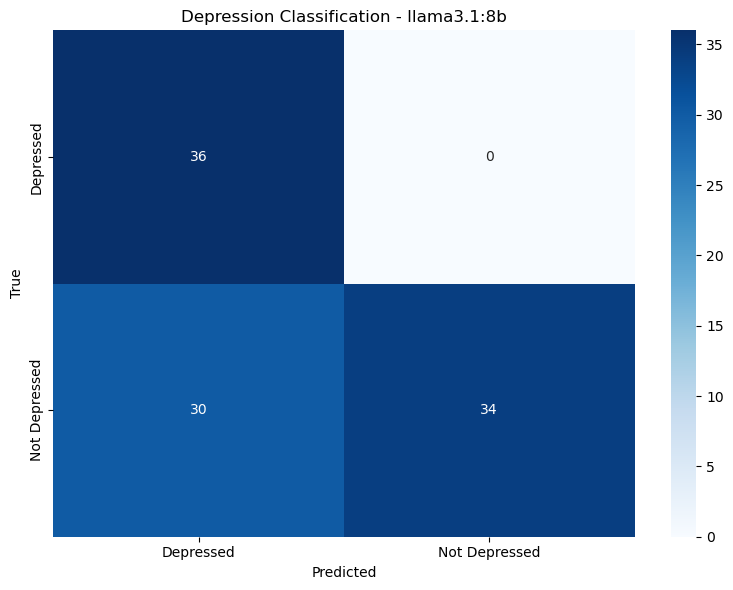

INFO:Chatbot:Trying stress assessment with model: qwen3:1.7b




Testing stress level precision and depression classification with qwen3 model (qwen3:1.7b)...


INFO:Chatbot:Model response: <think>
Okay, let's see. The user provided answers to a mental health assessment. I need to estimate their overall stress level from 1 to 5. Let me go through each answer and note any indicators of stress.

Answer 1: Mood is rated as 2 - feeling down. That's a moderate down mood, maybe a sign of stress.

Answer 2: Enjoying activities usually pleasurable. The answer is yes. Not sure if that's a stress indicator or just a normal response. Maybe not directly related.

Answer 3: Sleep is poor. Poor sleep is a common symptom of stress, so that's a red flag.

Answer 4: Energy levels are average. Not too high or low, so maybe not a stress indicator.

Answer 5: Appetite is very poor. Poor appetite can be linked to stress or other issues, but not sure if it's the main stress indicator.

Answer 6: Concentration is rarely. Difficulty concentrating is a stress symptom.

Answer 7: Often feeling overwhelmed. That's a strong indicator of high stress.

Answer 8: Outlook on

Sample 1: Target=4, Stress_Pred=1, Stress_True=5, Depression_Pred=No, Depression_True=Yes, Time=12.41s


ERROR:Chatbot:Request to model qwen3:1.7b timed out.
INFO:Chatbot:Trying stress assessment with model: gemma3:4b
INFO:Chatbot:Model response: 3
INFO:Chatbot:Trying stress assessment with model: qwen3:1.7b


...

Sample 98: Target=3, Stress_Pred=1, Stress_True=4, Depression_Pred=No, Depression_True=Yes, Time=17.48s


INFO:Chatbot:Model response: <think>
Okay, let's see. The user provided answers to a mental health assessment. I need to estimate their overall stress level from 1 to 5. Let me go through each answer one by one.

First answer: Mood is rated 4 - I Feel Good. So that's a positive mood, which would suggest low stress. 

Second answer: Enjoying activities usually pleasurable. That's a good sign, no stress there.

Third answer: Sleep is good. Good sleep is usually associated with low stress.

Fourth answer: Energy levels are very good. High energy is good, so not stressed.

Fifth answer: Appetite is average. No indication of stress here.

Sixth answer: Can concentrate on tasks often. Good concentration, so not stressed.

Seventh answer: Often feel overwhelmed. Wait, this is a problem. The answer is "Often," which might indicate high stress. 

Eighth answer: Outlook on future is positive. That's good.

Ninth answer: Supported by friends and family. That's a positive factor.

Tenth answer: Ne

Sample 99: Target=1, Stress_Pred=1, Stress_True=1, Depression_Pred=No, Depression_True=No, Time=10.27s


INFO:Chatbot:Model response: <think>
Okay, let's see. The user provided their answers to a mental health assessment. I need to estimate their overall stress level from 1 to 5. Let me go through each answer one by one.

First answer: Mood is 3, neutral. That's not too high or low. Next, they say they enjoy activities usually pleasurable. That's good, so maybe not stressed. Then sleep is poor, which is a common indicator of stress. Energy levels are very good, which is good. Appetite is good, so that's positive. Concentration is rarely able to focus, which could be a sign of stress. Overwhelmed sometimes—this is a key indicator. Outlook is neutral, not too bad. Supported by friends and family a little, which is moderate. Thoughts about life not being worth living: never, so that's good.

So the stress factors here are sleep being poor, concentration issues, and feeling overwhelmed. The other answers are neutral or good. The question is about overall stress level. Even though there are so

Sample 100: Target=3, Stress_Pred=1, Stress_True=2, Depression_Pred=No, Depression_True=No, Time=5.34s

=== qwen3 Prediction Distribution ===
Stress Level 1: 94 predictions
Stress Level 2: 0 predictions
Stress Level 3: 1 predictions
Stress Level 4: 5 predictions
Stress Level 5: 0 predictions
Total Depression Predictions: 5
Total True Depression Cases: 38

=== Stress Level Results ===
Stress Level - Accuracy: 0.30, Avg Error: 1.69
Stress Level - Avg Precision: 0.26
Stress Level Precision by Level:
  Level 1: 0.31
  Level 2: 0.00
  Level 3: 1.00
  Level 4: 0.00
  Level 5: 0.00

=== Depression Classification Results ===
Depression - Accuracy: 0.65, Precision: 0.80, Recall: 0.11, F1: 0.19
Average Response Time: 11.00s


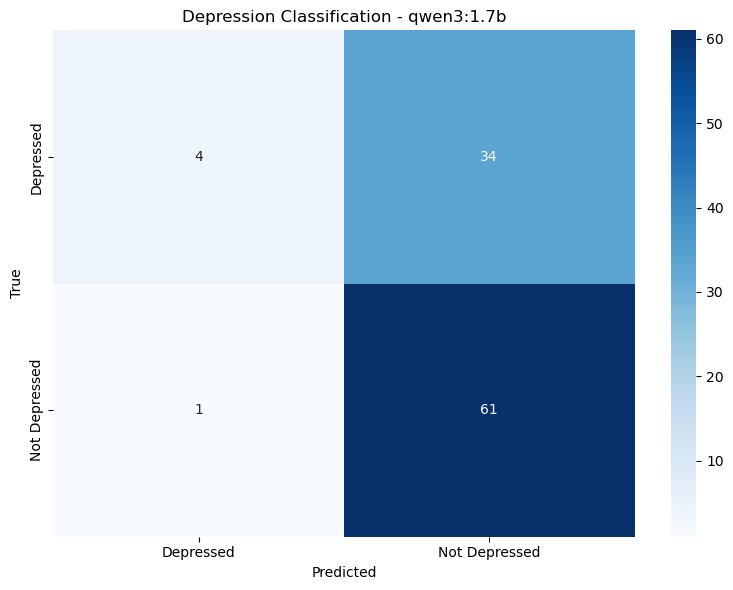

INFO:Chatbot:Trying stress assessment with model: deepseek-r1:7b




Testing stress level precision and depression classification with deepseek model (deepseek-r1:7b)...


ERROR:Chatbot:Request to model deepseek-r1:7b timed out.
INFO:Chatbot:Trying stress assessment with model: gemma3:4b
INFO:Chatbot:Model response: 3
INFO:Chatbot:Trying stress assessment with model: deepseek-r1:7b


Sample 1: Target=1, Stress_Pred=3, Stress_True=1, Depression_Pred=No, Depression_True=No, Time=37.60s


ERROR:Chatbot:Request to model deepseek-r1:7b timed out.
INFO:Chatbot:Trying stress assessment with model: gemma3:4b
INFO:Chatbot:Model response: 2
INFO:Chatbot:Trying stress assessment with model: deepseek-r1:7b


...

Sample 98: Target=5, Stress_Pred=4, Stress_True=5, Depression_Pred=Yes, Depression_True=Yes, Time=37.84s


ERROR:Chatbot:Request to model deepseek-r1:7b timed out.
INFO:Chatbot:Trying stress assessment with model: gemma3:4b
INFO:Chatbot:Model response: 3
INFO:Chatbot:Trying stress assessment with model: deepseek-r1:7b


Sample 99: Target=2, Stress_Pred=3, Stress_True=2, Depression_Pred=No, Depression_True=No, Time=37.53s


ERROR:Chatbot:Request to model deepseek-r1:7b timed out.
INFO:Chatbot:Trying stress assessment with model: gemma3:4b
INFO:Chatbot:Model response: 3


Sample 100: Target=3, Stress_Pred=3, Stress_True=2, Depression_Pred=No, Depression_True=No, Time=38.00s

=== deepseek Prediction Distribution ===
Stress Level 1: 5 predictions
Stress Level 2: 20 predictions
Stress Level 3: 36 predictions
Stress Level 4: 39 predictions
Stress Level 5: 0 predictions
Total Depression Predictions: 39
Total True Depression Cases: 40

=== Stress Level Results ===
Stress Level - Accuracy: 0.19, Avg Error: 0.91
Stress Level - Avg Precision: 0.29
Stress Level Precision by Level:
  Level 1: 1.00
  Level 2: 0.15
  Level 3: 0.11
  Level 4: 0.18
  Level 5: 0.00

=== Depression Classification Results ===
Depression - Accuracy: 0.93, Precision: 0.92, Recall: 0.90, F1: 0.91
Average Response Time: 37.85s


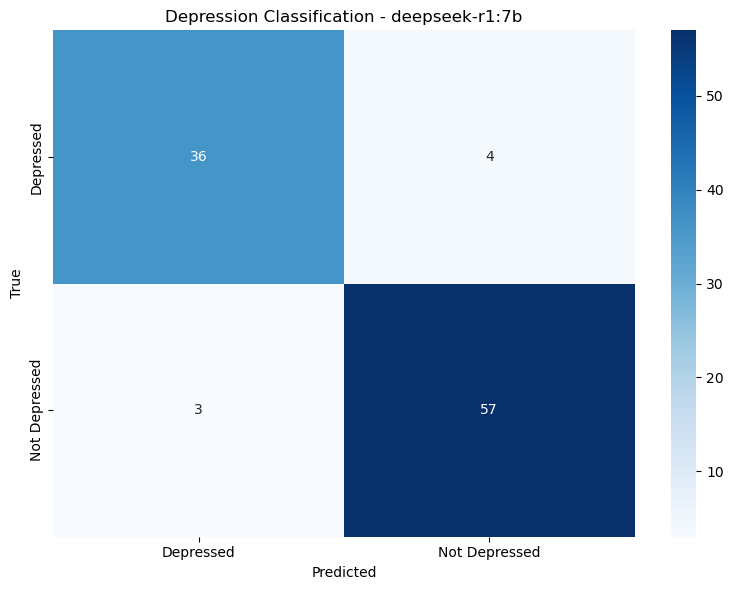




===== COMPREHENSIVE EVALUATION COMPARISON =====
         Model  Stress Accuracy  Stress Precision  Stress Error  Response Time (s)  Depression Accuracy  Depression Precision  Depression Recall  Depression F1
     gemma3:4b             0.23          0.317500          0.82           1.527653                 0.91              1.000000           0.780488       0.876712
   llama3.1:8b             0.14          0.185484          1.31           0.953751                 0.70              0.545455           1.000000       0.705882
    qwen3:1.7b             0.30          0.261702          1.69          11.002752                 0.65              0.800000           0.105263       0.186047
deepseek-r1:7b             0.19          0.288120          0.91          37.852740                 0.93              0.923077           0.900000       0.911392


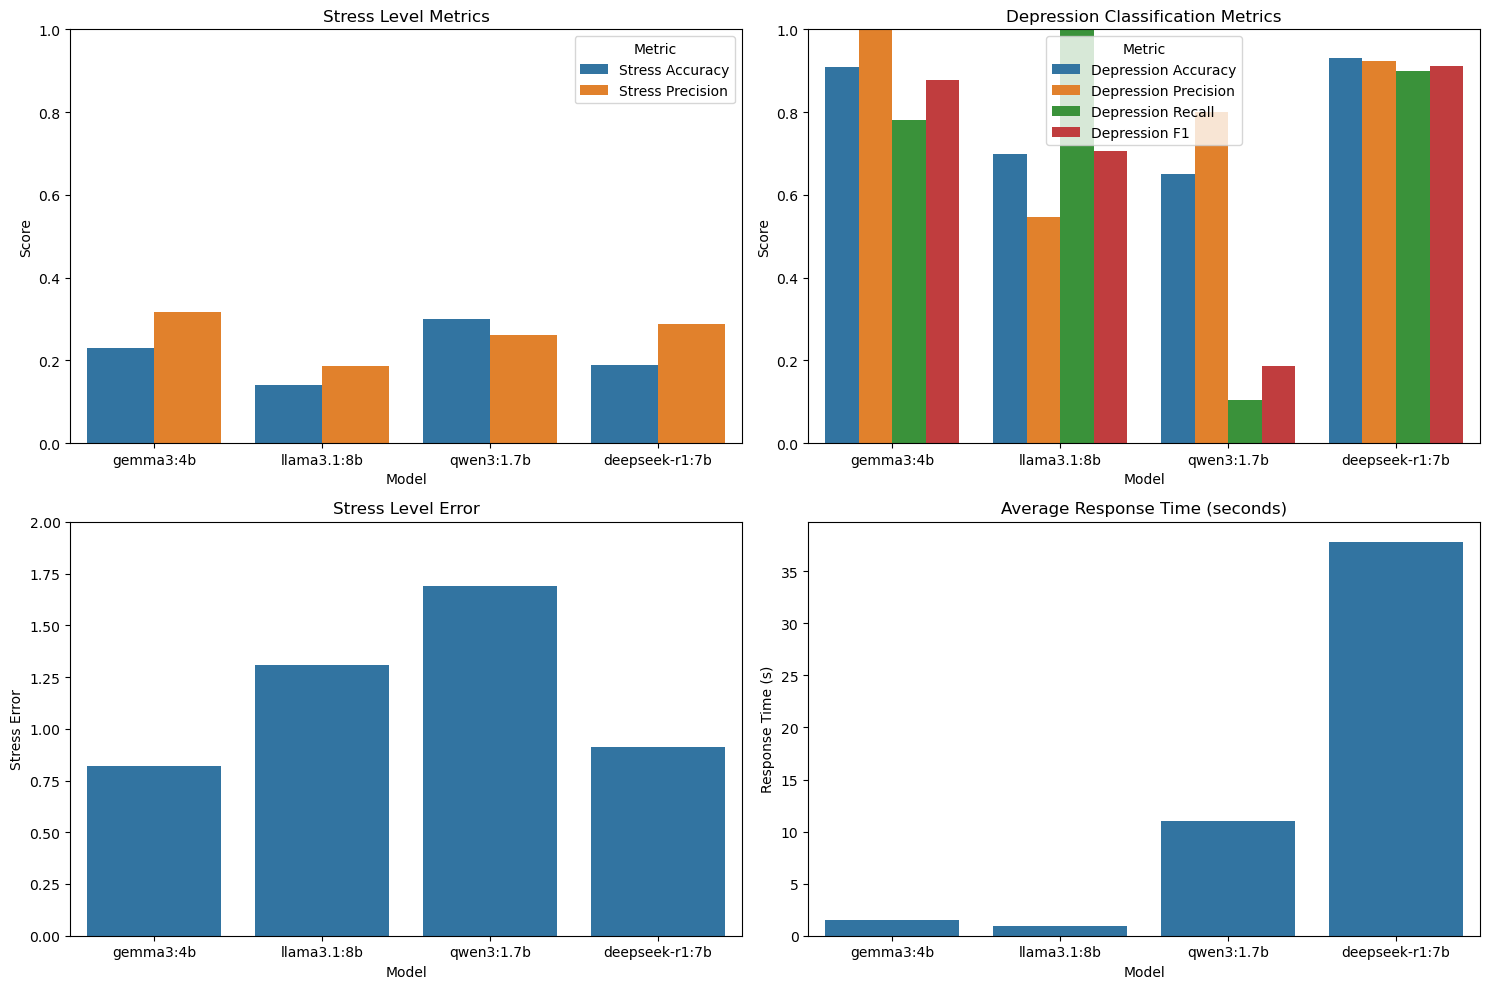


Evaluation completed in 5140.50 seconds


,Model,Stress Accuracy,Stress Precision,Stress Error,Response Time (s),Depression Accuracy,Depression Precision,Depression Recall,Depression F1
0,gemma3:4b,0.23,0.317500,0.82,1.527653,0.91,1.000000,0.780488,0.876712
1,llama3.1:8b,0.14,0.185484,1.31,0.953751,0.70,0.545455,1.000000,0.705882
2,qwen3:1.7b,0.30,0.261702,1.69,11.002752,0.65,0.800000,0.105263,0.186047
3,deepseek-r1:7b,0.19,0.288120,0.91,37.852740,0.93,0.923077,0.900000,0.911392


In [22]:
run_comprehensive_evaluation(num_samples=100)